# Preliminaries

In [15]:
from dolfin import *
from ufl import indices, Jacobian, Min, Max, And, shape
import numpy as np
import os, pygmsh, gmsh, meshio

In [16]:
# ploting customizations
from matplotlib import pyplot as plt
from matplotlib import tri, colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d
size=18
params = {'legend.fontsize': size*0.75,
        #   'figure.figsize': (20,8),
          'text.usetex': True,
          'text.latex.preamble': r'\usepackage{mathrsfs}',
        #   'mathtext.fontset': 'stix',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline

## Credit

Based heavily on [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi) from David Kamensky's [MAE 207: FEA for coupled problems](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master) course at UC San Diego.

Initial version written by U. Rade, Purdue University, for the simulations in the paper "Theory and simulation of elastoinertial rectification of oscillatory flows in two-dimensional deformable rectangular channels" (preprint [arXiv:2505.22799](https://arxiv.org/abs/2505.22799)).

Next rewrite by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot):
- converting to notebook format, 
- switching to gmsh for meshing, 
- adding steady analytical solution comparisons,
- implementing Carreau viscosity model,
- various other small improvements.

If you want to run this solver as a standalone python script (stripping all Markdown comments, etc), run the following command in your terminal:

`
jupyter nbconvert new_ALE-FSI_2D.ipynb --to python --PythonExporter.exclude_markdown=True
`

which creates the file `new_ALE-FSI_2D.py`.

## Introduction

Sketch of the geometry and notation.

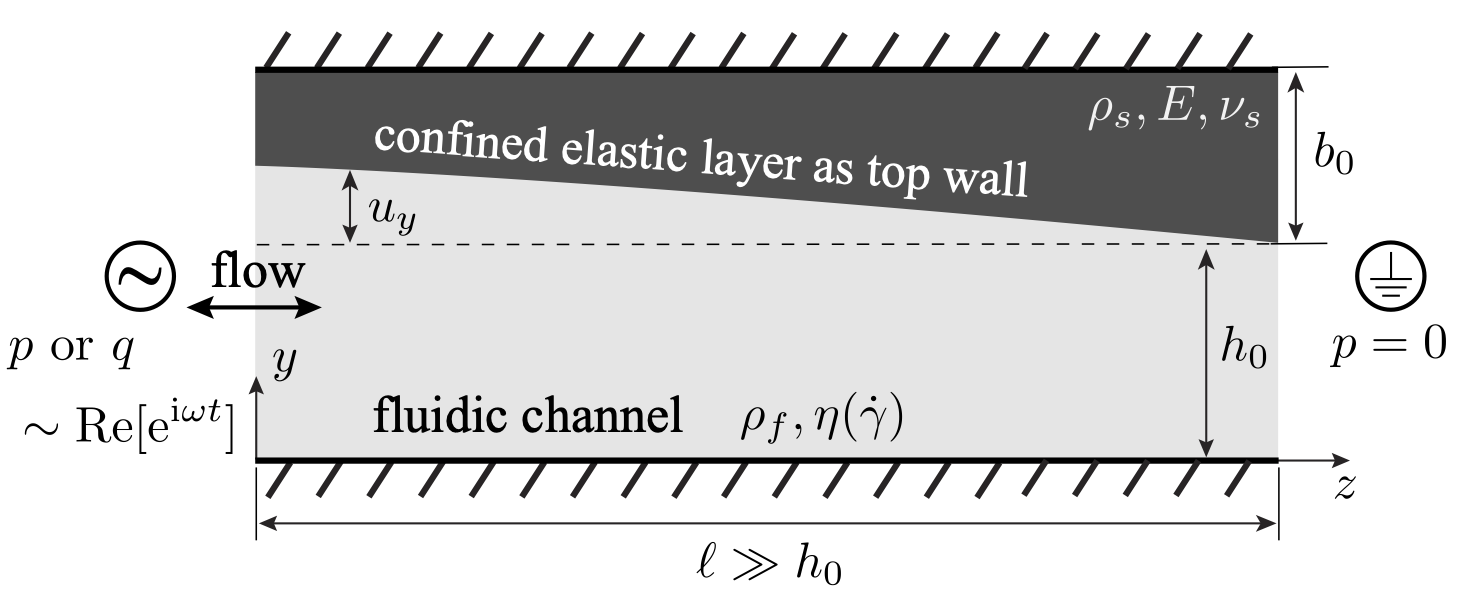

<span style="color: red">WARNING:</span> Carreau model is only implemented in the numerics, not in the theory.

# Problem setup

## Simulation settings

### Data storage

In [17]:
# If the folder does not exist, create it.
# I'm using a folder that will not get synced to GitHub.
DataFolder = "not-ready-for-github/simulation_output/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output/


### Algorithmic settings

Shouldn't require changing.

In [ ]:
LSIC            = True      # Least-squares incompressibility stabilization for fluid
BACKFLOW_STAB   = True      # Backflow stabilization for fluid
SUPG            = True      # Streamline Upwind Petrov-Galerkin stabilization for fluid
                            # shouldn't needed for low Re flow

print("============================ INFO ===========================")
print(f"SUPG stabilization:       {'ON' if SUPG else 'OFF'}")
print(f"LSIC stabilization:       {'ON' if LSIC else 'OFF'}")
print(f"Backflow stabilization:   {'ON' if BACKFLOW_STAB else 'OFF'}")
print("=============================================================")

============================ INFO ===========================
SUPG stabilization:       ON
LSIC stabilization:       ON
Backflow stabilization:   ON


### Parameters defining domain geometry

In [19]:
b0 = 0.01
h0 = b0
l  = 50*h0
# Solid domain extents:
SOLID_TOP    = h0+b0
SOLID_BOTTOM = h0
SOLID_LEFT   = 0.0
SOLID_RIGHT  = l
# Combined domain size:
OMEGA_H      = h0+b0
OMEGA_W      = l
# Flags for subdomains:
FLUID_FLAG   = 0
SOLID_FLAG   = 1
# Desired resolution of mesh:
N = 200 # 600
# Refine near inlet in SOLID domain only
inlet_refinement_solid_only = True
inlet_refinement = 0.33 # 1 = no refinement, 1/() times finer
# Refinement near fluid-solid interface
interface_refinement = 0.33 # 1 = no refinement, 1/() times finer

### Time stepping details

In [20]:
RAMP_TIME  = 0.1            # time over which BC is ramped up from 0 to full value
FINAL_TIME = 2*RAMP_TIME    # final time of simulation
N_T_STEPS  = 100            # number of time steps
N_SKIP     = 5              # save simulation output to file every N_SKIP time steps

Dt = Constant(FINAL_TIME/N_T_STEPS)
print("Time step is", float(Dt))

Time step is 0.002


### Material properties (dimensional)

In [21]:
# Elastic solid's properties:
E_s    = 7.5e+5                         # Young's modulus
nu_s   = 0.45                           # Poisson ratio
mu_s   = Constant(E_s/(2*(1+nu_s)))     # Shear modulus
K      = Constant(E_s/(3*(1-2*nu_s)))   # Bulk modulus
rho_s0 = Constant(1e6)
cs     = sqrt(mu_s/rho_s0)              # Shear wave speed in solid
print("Shear wave speed in solid is", f"{float(cs):.4g}")   # .4g = 4 sig figs

# Viscous fluid properties to yield desired dimensionless numbers,
# based on dynamic similarity:
rho_f    = Constant(0.5)
mu_f_0   = Constant(1.0)   # 0.1
mu_f_inf = Constant(0.0)   # 0.01 or 0.0001
n        = Constant(1.0)   # 0.5
lam_r    = Constant(0.0)   # 10.0

Shear wave speed in solid is 0.5085


### Boundary conditions (analyical)

In [22]:
omega = 0.0                                        # angular frequency for oscillatory case only

# For ramped-up steady pressure BC:
p_amp = Constant(2e5)                              # pressure amplitude
p_in  = Expression("p0*(t < tr?t/tr : 1.0)", 
                   p0=float(p_amp), tr=float(RAMP_TIME), t=0.0, degree=1)

# For oscillatory pressure BC:
# p_in  = Expression("p0*cos(w*t)", 
#                    p0=float(p_amp), w=float(omega), t=0.0, degree=1)

# For ramped-up steady flow-rate BC:
q_amp = Constant(0.1)                              # flow rate amplitude
v_in  = Expression(("x[1]<h0 ? 6*(q0*(t<tr ? t/tr : 1.0)/h0)*(x[1]/h0)*(h0-x[1])/h0 : 0.0", "0.0"), 
                   tr=float(RAMP_TIME), q0=float(q_amp), h0=float(h0), t=0.0, degree=2)

# For oscillayory flow-rate BC:
# v_in  = Expression(("x[1]<h0 ? 6*(q0/h0)*cos(w*t)*(x[1]/h0)*(h0-x[1])/h0 : 0.0", "0.0"), 
#                    q0=float(q_amp), w=float(omega), h0=float(h0), t=0.0, degree=2)


# Choose flow or pressure controlled BC:
FLOW_OR_PRESSURE = "PRESSURE"  # "FLOW" or "PRESSURE"
print(f"Using {FLOW_OR_PRESSURE}-controlled BC.")

Using PRESSURE-controlled BC.


### Dimensionless numbers

In [23]:
# Adjust scales for either flow rate or pressure control BC:
if FLOW_OR_PRESSURE == "FLOW":
    q_c = q_amp
    v_c = q_c/h0
    p_c = mu_f_0*q_c*l/h0**3
    dp_rigid = 12.0*float(p_c)
    q_rigid = float(q_c)    
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c = p_amp
    q_c = (p_c/l)*(h0**3/mu_f_0)
    v_c = q_c/h0
    dp_rigid = float(p_c)
    q_rigid = float(q_c/12.0)    
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

In [24]:
epsilon_f = h0/l                                             # Fluid (inverse) aspect ratio
epsilon_s = b0/l                                             # Solid (inverse) aspect ratio

C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s/l**2)    # Incompressible foundation compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*(b0/mu_s)                      # Winkler foundation compliance
C_H = (nu_s-1/4)/(1-nu_s)*(b0**2/mu_s/l)                     # Horizontal component compliance
theta = float(C_I/C_w)
vartheta = float(C_H/C_w)
beta = float(p_c/(h0/C_w))                                   # Compliance number

Wo = sqrt(h0**2 * omega/float(mu_f_0/rho_f))                 # Womersley number

gamma = float(C_w*l*mu_f_0*omega/(epsilon_f*h0**2))          # Elastoviscous number

#Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/mu_f**2)      # Reynolds number
Re = float(epsilon_f * rho_f * v_c * h0/mu_f_0) 
#Re = float(Wo**2 * beta/gamma)                              # Only if unsteady


print("============================ INFO ===========================")
print(f"ε_f = {epsilon_f:.5f}")
print(f"ε_s = {epsilon_s:.5f}")
print(f"θ   = {theta:.5f}")
print(f"β   = {beta:.5f} (compliance #)")
print(f"Wo  = {Wo:.5f} (Womersley #)")
print(f"γ   = {gamma:.5f} (Elastoviscous #)")
print(f"εRe = {Re:.5f} (Reynolds #)")
print("=============================================================")

============================ INFO ===========================
ε_f = 0.02000
ε_s = 0.02000
θ   = 0.00087
β   = 0.07030 (compliance #)
Wo  = 0.00000 (Womersley #)
γ   = 0.00000 (Elastoviscous #)
εRe = 0.00400 (Reynolds #)


## Analytical solutions: for comparisons, etc

### Rigid channel

Currently, implementing only the steady 2D channel flow solution.

**TODO:** Implement oscillatory (Womersley) 2D channel flow solution.

In [25]:
# Note that "x" in v_in and/or p_in is really "y" in the kinematics described below,
# but, because the mesh motion problem has a zero Dirichlet BC on the inflow boundary, 
# there happens to be no difference between "x" and "y".

# x[1] < h0 is needed if we want to evaluate this 
# over the whole Omega domain as an initial condition
p_rigid = Expression("x[1] < h0 ? (dp/L)*(L-x[0]) : 0.0", 
                     dp=float(p_amp), h0=float(h0), L=float(l), degree=1)
v_rigid = v_in

p_rigid.dp = float(dp_rigid)
v_rigid.q0 = float(q_rigid)

### Compliant channel

Implenting

1. "[Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits](https://dx.doi.org/10.1088/1361-648X/ac327d)" (preprint [arXiv:2106.07164](https://arxiv.org/abs/2106.07164)) for the flow-controlled case (Eq. (41) and related results), 

2. "[Oscillatory flows in compliant conduits at arbitrary Womersley number](https://dx.doi.org/10.1103/PhysRevFluids.8.124102)" (preprint [arXiv:2304.00543](https://arxiv.org/abs/2304.00543)) for the pressure-controlled case (see Eq. (A.2) and related results).

In [26]:
if FLOW_OR_PRESSURE == "FLOW":
   p_sh = Expression("pc/b*(pow(1 + 48.0*b*(1.0-x[0]/L),0.25) - 1.0)", 
                     pc=float(p_c), b=float(beta), L=float(l), degree=1)
   q_sh_in = q_sh_out = q_rigid
elif FLOW_OR_PRESSURE == "PRESSURE":
   p_sh = Expression("pc/b*(pow(pow(1.0+b,4.0) - ((pow(1.0+b,4.0)-1.0)*x[0]/L), 0.25) - 1.0)", 
                     pc=float(p_c), b=float(beta), L=float(l), degree=4)
   # now the flow rate is found from the pressure gradient at x = 0 and the rigid v profile
   dp_shdz0 = -(p_c/l)*((2+beta)*(2+2*beta+beta**2))/(4*(1+beta)**3)
   dp_shdzL = -(p_c/l)*((-1+(1+beta)**4))/(4*beta)
   # taking into account wall deformation h0 -> h0+Cw p, q = const again
   q_sh = q_sh_in = q_sh_out = (-dp_shdz0)*((h0+C_w*p_sh(0))**3/mu_f_0)/12.0
   #q_sh_out = (-dp_shdzL)*((h0+C_w*p_sh(l))**3/mu_f)/12.0
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

## Domain and mesh

Gmsh-based geometry & mesh.

In [27]:
# Generate custom mesh generation with local refinements:
from build_mesh_with_gmsh import build_mesh_with_gmsh

xdmf_path = build_mesh_with_gmsh(N,
                                 [0.0, OMEGA_W, 0.0, OMEGA_H, SOLID_BOTTOM],
                                 DataFolder+"fsi_rect",
                                 inlet_refinement=inlet_refinement, 
                                 inlet_refinement_solid_only=inlet_refinement_solid_only,
                                 interface_refinement=interface_refinement)

# Without any refinement (behaves like original code)
# xdmf_path = build_mesh_with_gmsh(h)

# Load back into dolfin from XDMF:
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Load back into dolfin from XDMF:
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Mesh-derived quantities:
d   = mesh.geometry().dim()
n_y = FacetNormal(mesh)
I   = Identity(d)

Info    : Found interface curve 4: x = [-0.000000, 0.500000], y = 0.010000                                  
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.190773s, CPU 0.275268s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.139362s, CPU 0.216519s)
Info    : 4401 nodes 9297 elements
Info    : Writing 'not-ready-for-github/simulation_output/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output/fsi_rect.msh'



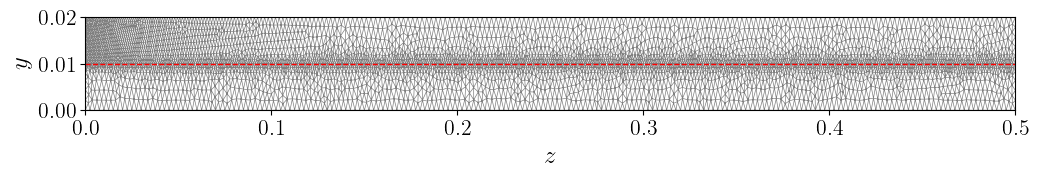

In [28]:
# Visualize the mesh real quick:
plot(mesh)
plt.gca().lines[0].set_linewidth(0.5)
plt.gca().set_aspect(2.5/1)
plt.gca().set_xlim(0, l)
plt.gca().set_xlabel("$z$")
plt.gca().set_ylabel("$y$")
plt.gca().set_ylim(0, h0+b0)
plt.gcf().set_size_inches(12, 6)
plt.plot(np.linspace(0, l, 10), np.ones(10)*(h0+b0)/2,
         linestyle='--', linewidth=1.0, color='red')
plt.show()

In [29]:
# Define subdomains for use in boundary condition definitions:
class Wall_b(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[1] < DOLFIN_EPS))

class Wall_t(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[1] > SOLID_TOP - DOLFIN_EPS))

class Wall_l(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] < DOLFIN_EPS)
                and x[1] > SOLID_BOTTOM - DOLFIN_EPS)

class Wall_r(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] > SOLID_RIGHT - DOLFIN_EPS)
                and x[1] > SOLID_BOTTOM - DOLFIN_EPS)

class Inflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] < DOLFIN_EPS)
                and x[1] < SOLID_BOTTOM + DOLFIN_EPS)

class Outflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] > (OMEGA_W - DOLFIN_EPS))
                and x[1] < SOLID_BOTTOM + DOLFIN_EPS)

class SolidDomainClosure(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > SOLID_BOTTOM - DOLFIN_EPS
                and x[0] > SOLID_LEFT - DOLFIN_EPS
                and x[0] < SOLID_RIGHT + DOLFIN_EPS)

class SolidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[0] > SOLID_LEFT - DOLFIN_EPS
                and x[0] < SOLID_RIGHT + DOLFIN_EPS
                and x[1] < SOLID_TOP + DOLFIN_EPS
                and x[1] > SOLID_BOTTOM + DOLFIN_EPS)

In [30]:
# Markers instead of mshr.domains():
markers = MeshFunction('size_t', mesh, d)
markers.set_all(FLUID_FLAG)                      # default: fluid = 0
SolidDomainClosure().mark(markers, SOLID_FLAG)   # reset: solid = 1

# Facet markers (0 = default):
facet_tags = MeshFunction('size_t', mesh, d-1, 0)

# Mark boundaries with IDs, if you wish:
# BOTTOM, LEFT, RIGHT, TOP = 11, 12, 13, 14
# Wall_b().mark(facet_tags, BOTTOM)
# Wall_l().mark(facet_tags, LEFT)
# Wall_r().mark(facet_tags, RIGHT)
# Wall_t().mark(facet_tags, TOP)
INFLOW, OUTFLOW = 3, 2 
Inflow().mark(facet_tags, INFLOW)
Outflow().mark(facet_tags, OUTFLOW)

# Quadrature-aware exterior measure with facet markers:
dx = dx(metadata={'quadrature_degree': 2}, subdomain_data=markers)
ds = ds(metadata={'quadrature_degree': 2}, subdomain_data=facet_tags)

# Variational problem definitions

## Elements and function spaces

In [31]:
# Define function spaces (equal order interpolation):
cell = mesh.ufl_cell()
Ve = VectorElement("CG", cell, 1)
Qe = FiniteElement("CG", cell, 1)
VQe = MixedElement((Ve,Qe))

# Mixed function space for velocity and pressure:
W = FunctionSpace(mesh, VQe)

# Function space for mesh displacement field, 
# which will be solved for separately in a 
# quasi-direct scheme:
V = FunctionSpace(mesh,Ve)

## Time integration variables

In [32]:
# Mesh motion functions:
uhat = Function(V)
uhat_old = Function(V)
du = TestFunction(V)
vhat = (uhat-uhat_old)/Dt

# Fluid--structure functions:
(dv, dp) = TestFunctions(W)
w = Function(W)
v,p = split(w)
p_mean = Function(W)
w_old = Function(W)
v_old, p_old = split(w_old)
dv_dr = (v - v_old)/Dt
dv_ds = dv_dr # (Only valid in solid)

# This is the displacement field used in the 
# solid formulation; notice that it is NOT 
# in the space V; it is an algebraic object 
# involving the unknown fluid--structure velocity 
# field v.
u = uhat_old + Dt*v

# This will need to be updated to match u, for 
# purposes of setting the boundary condition 
# on the mesh motion subproblem.
u_func = Function(V)

## ALE kinematics (change of variables)

In [33]:
# Follow notation from Bazilevs et al., where y is 
# the coordinate in the reference domain, x is the 
# coordinate in the spatial domain, and X is the 
# coordinate in the material domain.  Note that 
# the built-in differential operators (e.g., grad, 
# div, etc.) and integration measures (e.g., dx, ds, 
# etc.) are w.r.t. the reference configuration, y, 
# which is the mesh that FEniCS sees.  
dX = dx(SOLID_FLAG)
dy = dx
ds_y = ds

grad_y = grad
grad_X = grad # (Only valid in solid)

y = SpatialCoordinate(mesh)
x = y + uhat

det_dxdy = det(grad_y(x))

def grad_x(f):
    return dot(grad_y(f),inv(grad_y(x)))

def div_x(f): # (For vector-valued f)
    return tr(grad_x(f))

def div_x_tens(f): # (For (rank-2) tensor-valued f)
    i,j = indices(2)
    return as_tensor(grad_x(f)[i,j,j],(i,))

# Note:  Trying to define dx = det_dxdy*dy would 
# result in an object of type Form, which could no 
# longer be used as an integration measure.
# Thus, integration over the spatial configuration 
# is done with det_dxdy*dy directly in the fluid 
# formulation.  

## Boundary conditions (simulation)

In [34]:
# BCs for the fluid--structure subproblem:
bc_b_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_b())
bc_l_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_l())
bc_r_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_r())
bc_t_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_t())

# Inlet BC: either flow rate or pressure
if FLOW_OR_PRESSURE == "FLOW":
    bc1_fs = DirichletBC(W.sub(0), v_in, Inflow())
elif FLOW_OR_PRESSURE == "PRESSURE":
    bc1_fs = DirichletBC(W.sub(1), p_in, Inflow())
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

bc2_fs = DirichletBC(W.sub(1), Constant(0.0), SolidDomainInterior())                     

bcs_fs = [bc_b_fs, bc_l_fs, bc_r_fs, bc_t_fs, bc1_fs, bc2_fs]
#bcs_fs = [bc_b_fs, bc1_fs, bc2_fs]

# BCs for the mesh motion subproblem:
#bc_m_wall_b  = DirichletBC(V.sub(1), Constant(0.0), Wall_b())
#bc_m_wall_t  = DirichletBC(V.sub(1), Constant(0.0), Wall_t())
bc_m_wall_b  = DirichletBC(V, Constant(d*(0.0,)), Wall_b())
bc_m_wall_t  = DirichletBC(V, Constant(d*(0.0,)), Wall_t())
# Roller BCs on left & right walls of solid & fluid domain:
#bc_m_wall_l  = DirichletBC(V.sub(0), Constant(0.0), Wall_l())
#bc_m_wall_r  = DirichletBC(V.sub(0), Constant(0.0), Wall_r())
#bc_m_inflow  = DirichletBC(V.sub(0), Constant(0.0), Inflow())
#bc_m_outflow = DirichletBC(V.sub(0), Constant(0.0), Outflow())
# "Full" Dirichlet BCs on left & right walls of solid & fluid domain:
bc_m_wall_l  = DirichletBC(V, Constant(d*(0.0,)), Wall_l())
bc_m_wall_r  = DirichletBC(V, Constant(d*(0.0,)), Wall_r())
bc_m_inflow  = DirichletBC(V, Constant(d*(0.0,)), Inflow())
bc_m_outflow = DirichletBC(V, Constant(d*(0.0,)), Outflow())

bc_m_struct  = DirichletBC(V, u_func, SolidDomainClosure())

bcs_m        = [bc_m_struct, 
                bc_m_wall_b, bc_m_wall_l, bc_m_wall_r, bc_m_wall_t, 
                bc_m_inflow, bc_m_outflow]

## Mesh motion subproblem

In [35]:
# Residual for mesh, which satisfies a fictitious elastic problem:
F_m = grad_y(uhat) + I
E_m = 0.5*(F_m.T*F_m - I)
m_jac_stiff_pow = Constant(3.0)

# Artificially stiffen the mesh where it is getting crushed:
K_m    = Constant(1.0)/pow(det(F_m),m_jac_stiff_pow)
mu_m   = Constant(1.0)/pow(det(F_m),m_jac_stiff_pow)
S_m    = K_m*tr(E_m)*I + 2.0*mu_m*(E_m - tr(E_m)*I/3.0)
res_m  = (inner(F_m*S_m,grad_y(du)))*dy
Dres_m = derivative(res_m, uhat)

## Solid subproblem


In [36]:
# Kinematics:
F = grad_X(u) + I  
E = 0.5*(F.T*F - I)
S = K*tr(E)*I + 2.0*mu_s*(E - tr(E)*I/3.0)
f_s = Constant(d*(0,))
res_s = rho_s0*inner(dv_ds - f_s,dv)*dX + inner(F*S,grad_X(dv))*dX

## Fluid subproblem


In [37]:
# Shear rate helper function:
def gamma_dot(v):
    E_f = sym(grad_x(v))
    return sqrt(2.0*inner(E_f, E_f) + DOLFIN_EPS)

# Effective viscosity (Carreau model):
def mu_eff(v):
    return mu_f_inf + (mu_f_0 - mu_f_inf) \
           * (1.0 + (lam_r*gamma_dot(v))**2.0)**((n-1.0)/2.0)

# Cauchy stress of the fluid:
sigma_f = 2.0*mu_eff(v)*sym(grad_x(v)) - p*I

# Convective term of the fluid:
v_adv    = v - vhat
DvDt     = dv_dr + dot(grad_x(v),v_adv)
resGal_f = (rho_f*dot(DvDt,dv) + inner(sigma_f,grad_x(dv))
            + dp*div_x(v))*det_dxdy*dy(FLUID_FLAG)

# Stabilization:

# Deformed mesh size tensor in the spatial configuration:
J_m = Jacobian(mesh)                
dxi_dy = inv(J_m)
dxi_dx = dxi_dy*inv(grad_y(x))
G = (dxi_dx.T)*dxi_dx

# SUPG/PSPG:
resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)
Cinv = Constant(1.0)
tau_M = 1.0/sqrt(((2*rho_f/Dt)**2) 
                 + inner(rho_f*v_adv,G*(rho_f*v_adv))
                 + Cinv*(mu_f_0**2)*inner(G,G))
resSUPG_f = inner(tau_M*resStrong_f,
                  rho_f*dot(grad_x(dv),v_adv)
                  + grad_x(dp))*det_dxdy*dy(FLUID_FLAG)
# LSIC/grad-div:
tau_C = 1.0/(tr(G)*tau_M)
resLSIC_f = tau_C*div_x(v)*div_x(dv)*det_dxdy*dy(FLUID_FLAG)

# Stable Neumann BC term, assuming advective 
# form of material time derivative term and transforming
# normal and area element by Nanson's formula (on deforming mesh):
dsx_dsy_n_x = det_dxdy*inv(grad_y(x).T)*n_y
v_adv_minus = Min(dot(v_adv,dsx_dsy_n_x),Constant(0))
gm = Constant(1.0) # or 0.5
resOutflow_f = -gm*dot(rho_f*v_adv_minus*dv,v)*ds_y(OUTFLOW)
resInflow_f = -gm*dot(rho_f*v_adv_minus*dv,v)*ds_y(INFLOW)

# For inlet pressure BCs
if FLOW_OR_PRESSURE == "FLOW":
    Consistency_term = 0
elif FLOW_OR_PRESSURE == "PRESSURE":
    traction = -p_in*n_y
    Consistency_term = -(inner(det_dxdy*inv(grad_y(x).T)*traction,dv))*ds_y(INFLOW)
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

# Total fluid residual:
res_f = resGal_f
# and stabilization terms as needed:
if SUPG:  
    res_f += resSUPG_f
if LSIC:
    res_f += resLSIC_f
if BACKFLOW_STAB:
    res_f += resOutflow_f
# Add consistent traction at inlet to enforce pressure as Neumann BC:
if FLOW_OR_PRESSURE == "PRESSURE":
    res_f += Consistency_term

## Nonlinear solver(s) for the variational problems

In [38]:
# Nonlinear solver parameters; set relative tolerances 
# for subproblems tighter than tolerance for coupled problem, 
# to prevent stagnation.
REL_TOL_FSM   = 1e-5
REL_TOL_FS    = REL_TOL_M = REL_TOL_FSM*1e-1
MAX_ITERS_FSM = 100
MAX_ITERS_M   = 100
MAX_ITERS_FS  = 100

# Set up nonlinear problem for mesh motion:
problem_m = NonlinearVariationalProblem(res_m, uhat, bcs_m, Dres_m)
solver_m  = NonlinearVariationalSolver(problem_m)
solver_m.parameters['newton_solver']\
                   ['maximum_iterations'] = MAX_ITERS_M
solver_m.parameters['newton_solver']\
                   ['relative_tolerance'] = REL_TOL_M

# Residual of fluid--structure coupled problem:
res_fs = res_f + res_s 
Dres_fs = derivative(res_fs, w)

# Create variational problem and solver for 
# the fluid--structure problem:
problem_fs = NonlinearVariationalProblem(res_fs, w, bcs_fs, Dres_fs)
solver_fs  = NonlinearVariationalSolver(problem_fs)
solver_fs.parameters['newton_solver']\
                    ['maximum_iterations'] = MAX_ITERS_FS
solver_fs.parameters['newton_solver']\
                    ['relative_tolerance'] = REL_TOL_FS

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


# Time stepping

## Initial conditions

In [39]:
# # Interpolate into subspaces
# V_sub = W.sub(0).collapse()
# Q_sub = W.sub(1).collapse()

# v_n_init = interpolate(v_rigid, V_sub)
# p_n_init = interpolate(p_rigid, Q_sub)

# # Assign to mixed function
# assign(w_old, [v_n_init, p_n_init])

## Time stepping loop

In [40]:
# Create files for storing solution:
vfile = File(DataFolder+"velocity.pvd")
pfile = File(DataFolder+"pressure.pvd")
mfile = File(DataFolder+"mesh.pvd")

# Save initial condition to file:
# v_n_init.rename("v","v")
# p_n_init.rename("p","p")
# uhat.rename("u","u")
# vfile << v_n_init
# pfile << p_n_init
# mfile << uhat

# Prepare to store time-dependent post-processed quantities:
Qsave = []
time_array = []

# Initialize time and step counter:
t = float(Dt)
count = 0

# Prevent divide-by-zero in relative residual on first
# iteration of first step:
for bc in bcs_fs:
    bc.apply(w.vector())

while t <= FINAL_TIME:

    print(80*"=")
    print("  Time step "+str(count+1)+" , t = "+str(t))
    print(80*"=")
    
    # Update to the current time in the inflow BC:
    if FLOW_OR_PRESSURE == "FLOW":
        v_in.t = t
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_in.t = t
    else:
        raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")
    

    # "Quasi-direct" coupling: the fluid and structure 
    # are solved in one system, but the mesh is solved 
    # in a separate block.
    for i in range(0,MAX_ITERS_FSM):

        # Check fluid--structure residual on the moved
        # mesh, and terminate iteration if this residual 
        # is small:
        res_fs_vec = assemble(res_fs)
        for bc in bcs_fs:
            bc.apply(res_fs_vec,w.vector())
        res_norm = norm(res_fs_vec)
        if i==0:
            res_norm0 = res_norm
        res_rel = res_norm/res_norm0
        
        print(80*"*")
        print("  Coupling iteration: "+str(i+1)
              +" , Relative residual = "+str(res_rel))
        print(80*"*", flush=True)

        if res_rel < REL_TOL_FSM:
            break

        # Solve for fluid/structure velocity and 
        # pressure at current time:
        solver_fs.solve()
        
        # Update Function in V to be used in mesh 
        # motion BC.  (There are workarounds to avoid 
        # this projection (which requires a linear
        # solve), but projection is most concise for 
        # illustration.)
        u_func.assign(project(u,V))

        # Mesh motion problem; updates uhat at current 
        # time level:
        solver_m.solve()

   
    # Extract velocity and pressure solutions from w:
    (v, p) = w.split()

    # Post-process some time dependent quantities for later:
    Qin1 = assemble(dot(v,n_y)*ds_y(INFLOW))
    Qin2 = assemble(dot(v,dsx_dsy_n_x)*ds_y(INFLOW))
    Qout1 = assemble(dot(v,n_y)*ds_y(OUTFLOW))
    Qout2 = assemble(dot(v,dsx_dsy_n_x)*ds_y(OUTFLOW))    
    Qsave.append([Qin1,Qin2,Qout1,Qout2])
    time_array.append(t)

    # Save output files every N_SKIP time steps:
    if count % N_SKIP == 0:
        v.rename("v","v")
        p.rename("p","p")
        uhat.rename("u","u")
        vfile << v
        pfile << p
        mfile << uhat
     
    # Move to next time step:
    uhat_old.assign(uhat)
    w_old.assign(w)
    count += 1
    t += float(Dt)

  Time step 1 , t = 0.002
Calling FFC just-in-time (JIT) compiler, this may take some time.
********************************************************************************
  Coupling iteration: 1 , Relative residual = 1.0
********************************************************************************
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 3.225e+04 (tol = 1.000e-10) r (rel) = 1.000e+00 (tol = 1.000e-06)
  Newton iteration 1: r (abs) = 7.231e-02 (tol = 1.000e-10) r (rel) = 2.242e-06 (tol = 1.000e-06)
  Newton iteration 2: r (abs) = 6.420e-07 (tol = 1.000e-10) r (rel) = 1.991e-11 (tol = 1.000e-06)
  Newton solver finished in 2 iterations and 2 linear solver iterations.
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 5.031e-04 (tol = 1.000e-10) r (rel) = 1.000e+00 (tol = 1.000e-06)
********************************************************************************
  Coupling iteration: 2 , Relative residual = 8.87550799885409e-07
*****

# Visualization and post-processing

Some meshing preliminaries. 

We make horizontal scales dimensionless by dividing by $\ell$, and vertical scales dimensionless by dividing by $h_0+b_0$.

In [41]:
# Extract coordinates and displacement values:
coordinates = mesh.coordinates()
cells = mesh.cells()
dim = mesh.geometry().dim()
num_vertices = len(coordinates)
# Create triangulation and plot:
x_coords = coordinates[:, 0]/l
y_coords = coordinates[:, 1]/(h0+b0)
triang = tri.Triangulation(x_coords, y_coords, cells)

## Inlet/outlet flow rates

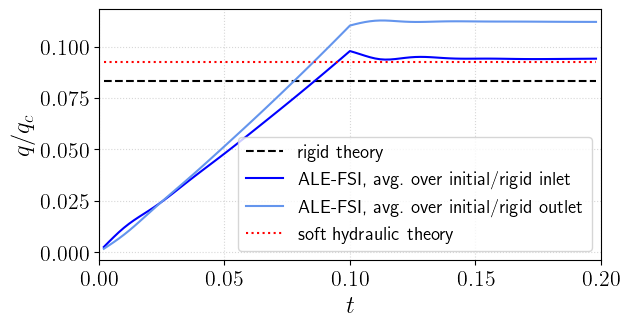

In [42]:
ime_array = np.array(time_array)
Qsave2 = np.array(Qsave) # this signed flow rate is negative because it is an inlet

# Create plot:
fig, ax = plt.subplots()
ax.plot(time_array, float(q_rigid/q_c)*np.ones(len(time_array)), 
        label='rigid theory', linestyle='dashed', color='black')

ax.plot(time_array, -Qsave2[:,0]/float(q_c), 
        label=r'ALE-FSI, avg.\ over initial/rigid inlet', color='blue')
#ax.plot(time_array, -Qsave2[:,1]/float(q_c), label=r"ALE-FSI, avg. using Nanson's formula")
ax.plot(time_array, Qsave2[:,2]/float(q_c), 
        label=r'ALE-FSI, avg.\ over initial/rigid outlet', color='cornflowerblue')
#ax.plot(time_array, Qsave2[:,3]/float(q_c), label=r"ALE-FSI, avg. using Nanson's formula")

ax.plot(time_array, float(q_sh/q_c)*np.ones(len(time_array)), 
        label='soft hydraulic theory', linestyle='dotted', color='red')

ax.set_xlabel('$t$')
ax.set_ylabel('$q/q_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, np.round(time_array[-1],2))
#ax.set_ylim(0, float(q_amp))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.tight_layout()
plt.show()

## Height-averaged axial pressure distribution

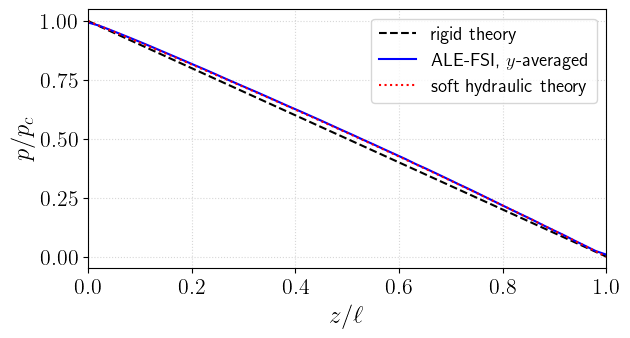

In [43]:
# Sampling parameters:
num_x_samples = 50
x_vals = np.linspace(SOLID_LEFT, SOLID_RIGHT, num_x_samples)
avg_p = []
avg_dpdx = []
avg_d2pdx2 = []

# Compute the derivative fields
Vp = p.function_space().collapse()
dpdx = project(grad(p)[0], Vp)
d2pdx2 = project(grad(dpdx)[0], Vp)

# Rigid and soft hydraulic pressures for comparison:
xy_vals = np.array([[x, 0] for x in x_vals])
pressure_rigid = np.array([p_rigid(xy) for xy in xy_vals])
pressure_sh = np.array([p_sh(xy) for xy in xy_vals])

# Loop over x-values and integrate p from the solution over y:
for x_loc in x_vals:
    # Create indicator function
    V0 = FunctionSpace(mesh, "DG", 0)  # Discontinuous Galerkin, piecewise constant
    strip_width = 1e-2
    class StripIndicator(UserExpression):
        def eval(self, value, x):
            if abs(x[0] - x_loc) <= strip_width/2:
                value[0] = 1.0
            else:
                value[0] = 0.0
        
        def value_shape(self):
            return ()
        
    # Interpolate onto function space:
    strip_expr = StripIndicator(degree=0)
    strip_func = interpolate(strip_expr, V0)
    
    # Now integrate:
    p_int = assemble(p * strip_func * dx(FLUID_FLAG))
    dpdx_int = assemble(dpdx * strip_func * dx(FLUID_FLAG))
    d2pdx2_int = assemble(d2pdx2 * strip_func * dx(FLUID_FLAG))
    strip_area = assemble(strip_func * dx(FLUID_FLAG))        
    
    if strip_area > DOLFIN_EPS:
        avg_p.append(p_int / strip_area)
        avg_dpdx.append(dpdx_int / strip_area)
        avg_d2pdx2.append(d2pdx2_int / strip_area)
    else:
        avg_p.append(0.0)
        avg_dpdx.append(0.0)
        avg_d2pdx2.append(0.0)

avg_p = np.array(avg_p)
avg_dpdx = np.array(avg_dpdx)
avg_d2pdx2 = np.array(avg_d2pdx2)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, pressure_rigid/float(p_c), 
        label='rigid theory', linestyle='dashed', color='black')
ax.plot(x_vals/l, avg_p/float(p_c), 
        label='ALE-FSI, $y$-averaged', color='blue')
ax.plot(x_vals/l, pressure_sh/float(p_c), 
        label='soft hydraulic theory', linestyle='dotted', color='red')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()


## Fluid&ndash;solid interface displacement and pressure

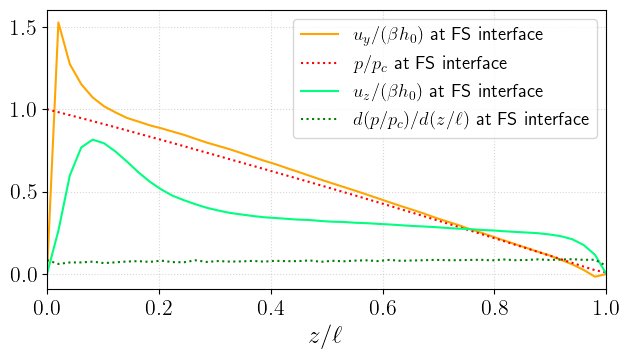

In [44]:
# Create points along the fluid-solid interface:
fs_line_points = [(x, h0) for x in x_vals]

# Evaluate the vertical displacement and pressure at each point:
u_fs_values = []
p_fs_values = []
dpdx_fs_values = []
d2pdx2_fs_values = []
for point in fs_line_points:
    u_fs_values.append(uhat(point))
    p_fs_values.append(p(point))
    dpdx_fs_values.append(dpdx(point))
    d2pdx2_fs_values.append(d2pdx2(point))

u_fs_values = np.array(u_fs_values)
p_fs_values = np.array(p_fs_values)
dpdx_fs_values = np.array(dpdx_fs_values)
d2pdx2_fs_values = np.array(d2pdx2_fs_values)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, u_fs_values[:,1]/float(beta*h0),
        label=r'$u_y/(\beta h_0)$ at FS interface', color='orange')
ax.plot(x_vals/l, p_fs_values/float(p_c), 
        label='$p/p_c$ at FS interface', color='red', linestyle='dotted')
ax.plot(x_vals/l, u_fs_values[:,0]/float(beta*h0),
        label=r'$u_z/(\beta h_0)$ at FS interface', color='springgreen')
ax.plot(x_vals/l, -vartheta*avg_dpdx/(float(p_c)/l), 
        label=r'$d(p/p_c)/d(z/\ell)$ at FS interface', color='green', linestyle='dotted')

ax.set_xlabel(r'$z/\ell$')
#ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()    

## Pressure contours

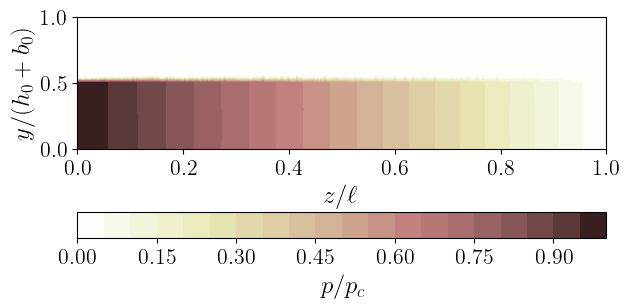

In [45]:
# Get pressure values at vertices:
pressure_values = p.compute_vertex_values(mesh)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, pressure_values/float(p_c), levels=20, cmap='pink_r')
fig.colorbar(contour,label='$p/p_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

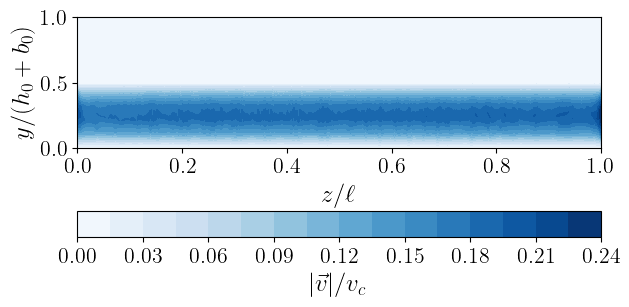

In [46]:
# Get velocity values at vertices:
vx, vy = v.split()
vx_values = vx.compute_vertex_values(mesh)
vy_values = vx.compute_vertex_values(mesh)

# Compute magnitude:
magnitude = np.sqrt(vx_values**2 + vy_values**2)

# Create plot:
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c), levels=20, cmap='Blues')
fig.colorbar(contour,label=r'$|\vec{v}|/v_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.tight_layout()
plt.show()

## Displacement magnitude contours

We will mask all $y/h_0 < h_0/(h_0+b_0)$ to show only the displacement fiend in the solid. There is mesh displacement in the fluid domain but we do not consider that to be "physical."

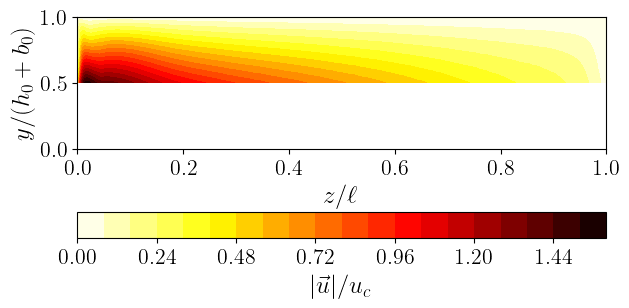

In [47]:
# Get displacement values at vertices:
ux, uy = uhat.split()
ux_values = ux.compute_vertex_values()
uy_values = uy.compute_vertex_values()

# Compute magnitude:
magnitude = np.sqrt(ux_values**2 + uy_values**2)
# Mask off fluid domain, need to deep copy the triang:
masked_triang =  tri.Triangulation(x_coords.copy(), y_coords.copy(), cells.copy())
masked_triang.set_mask(np.mean(y_coords[masked_triang.triangles], axis=1) < h0/(h0+b0))
# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(masked_triang, magnitude/float(beta*h0), levels=20, cmap='hot_r')

fig.colorbar(contour,label=r'$|\vec{u}|/u_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()